In [3]:
d = 251
print(381520/d) 
print(95380/d)

1520.0
380.0


In [4]:
380*4


1520

In [1]:
import json
import subprocess
import re
from itertools import product
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt


#with open("dpa_tune_settings.json", 'r') as file:
#        settings = json.load(file)

#print("output_dir:", settings['output_dir'])
#alt_output_dir = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output_missed_jobs/"
#print("alternative output_dir:", alt_output_dir)


In [6]:
# MAKE SURE THESE ARE CORRECTLY DEFINED
#latent_dims=[10, 20, 50]
#encoder=["learnable", "PCA"]
#hidden_dim_NNs=[50, 100]
#num_layers_NNs=[4, 6]
#noise_dim_dec=[5, 10, 20]
# latent map
#hidden_dim_lm=[20, 50]
#noise_dim_lm=[20, 100]
#training
#lambdas=[0.0, 0.5, 1.0]

###

output_dir = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning2_starting24112025_v3_data/"
# 1) Define your coordinate values
coords = {
    'latent_dim':    [10, 20, 50],
    'encoder':       ['learnable', 'PCA'],
    'hidden_dim_NN': [50, 100],
    'num_layers_NN': [4, 6],
    'noise_dim_dec': [5, 10, 20],
    'hidden_dim_lm': [20, 50],
    'noise_dim_lm':  [20, 100],
    'lamb':        [0.0, 0.5, 1.0],
    'epoch':         np.arange(1, 101),          # 0 … 100 inclusive
    'mode':          ['train', 'test'],
    'loss':          ['Total loss','Total S1','Total S2',
                      'DPA NRGY','DPA s1','DPA s2',
                      'LM NRGY','LM s1','LM s1']
}


#save_dir = f"{settings['output_dir']}_{latent_dim}_{num_layers}_{hidden_dim}_{noise_dim_dec}_{in_dim_lm}_{noise_dim_lm}_{num_layers_lm}_{hidden_dim_lm}_encoderis{encoder}_lambda{lam}/"

In [3]:
# Generate all combinations as tuples
combos = list(product(
    coords['latent_dim'],
    coords['encoder'],
    coords['hidden_dim_NN'],
    coords['num_layers_NN'],
    coords['noise_dim_dec'],
    coords['hidden_dim_lm'],
    coords['noise_dim_lm'],
    coords['lamb']
))

# If you prefer a list of dicts:
param_names = [
    "latent_dim", "encoder", "hidden_dim_NN", "num_layers_NN",
    "noise_dim_dec", "hidden_dim_lm", "noise_dim_lm", "lambda"
]
combo_dicts = [dict(zip(param_names, vals)) for vals in combos]

In [4]:
combo_dicts

[{'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 0.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 0.5},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 20,
  'lambda': 1.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 100,
  'lambda': 0.0},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 20,
  'noise_dim_lm': 100,
  'lambda': 0.5},
 {'latent_dim': 10,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hi

In [4]:
def load_and_validate(path, validator):
    """
    Load the file at `path` and run `validator(obj)`.
    Raise FileNotFoundError if missing, or ValueError if validator fails.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"No such file: {path}")
    
    # Example for JSON; swap out for pd.read_csv, pickle.load, etc.
    #with open(path, 'r') as f:
        #obj = json.load(f)
    df = pd.read_csv(
            path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )

    if not validator(df):
        raise ValueError(f"Validation failed for file: {path}")
    df_data = get_train_test(df)
    return df_data

def get_train_test(df):
    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()
    return train_array, test_array

# --- Your custom validation function ---
def col_no(df):
    train_array, test_array = get_train_test(df)
    
    if test_array.shape[0] == 100:
        prop = True
    else:
        print(f"[{i}] Test array length: {test_array.shape[0]}")
        prop = False
    return prop

In [5]:
# 2) Create an empty Dataset filled with NaNs
ds = xr.Dataset(
    coords={k: ( [k], v ) for k, v in coords.items()},
    data_vars={
        'value': ( list(coords.keys()), 
                   np.full([len(v) for v in coords.values()], np.nan) )
    }
)
# dims of ds['value'] are in the order of coords.keys()

# 3) Function to parse hyperparameters from filename
def parse_filename(fname):
    """
    example filename:
    _10_4_50_10_1001_20_2_50_encoderislearnable_lambda0.0
    _latentdim(0)_numlayers(1)_hiddendim(2)_noisedimdec(3)_indimlm(4)_noisedimlm(5)_numlayerslm(6)_hiddendimlm(7)_encoder(8)_lambda(9)
    Expect filenames like:
      '..._10_PCA_50_4_5_20_20_20_0.5.txt'
    in exactly the same order as coords (except epoch/mode/loss).
    """
    stem = Path(fname).name
    print(stem)
    parts = stem.split('_')
    print("Parts:", parts)
    #print(str(parts[8+1].split('is')[1]))
    print("lambda:", parts[9+1].split('bda')[1])
    return {
        'latent_dim':    int(parts[0+1]),
        'num_layers_NN': int(parts[1+1]),
        'hidden_dim_NN': int(parts[2+1]),
        'noise_dim_dec': int(parts[3+1]),
        'hidden_dim_lm': int(parts[7+1]),
        'noise_dim_lm':  int(parts[5+1]),
        'encoder':       str(parts[8+1].split('is')[1]),
        'lambda':        float(parts[9+1].split('bda')[1]),
    }
    


In [13]:
i = 1
while i < 432:
    print(i)
    save_path = (
        f"{output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderislearnable_"
        #f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}_bs128_bnisFalse/log.txt"
    )
    df = load_and_validate(save_path, col_no)
    file_path = Path(save_path)
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="train",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = train_losses
    ###
    # test loss
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="test",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = test_losses
    ###
    i += 1

1
_10_4_50_5_1001_20_2_20_encoderislearnable_lambda0.5_bs128_bnisFalse
Parts: ['', '10', '4', '50', '5', '1001', '20', '2', '20', 'encoderislearnable', 'lambda0.5', 'bs128', 'bnisFalse']
lambda: 0.5
2
_10_4_50_5_1001_20_2_20_encoderislearnable_lambda1.0_bs128_bnisFalse
Parts: ['', '10', '4', '50', '5', '1001', '20', '2', '20', 'encoderislearnable', 'lambda1.0', 'bs128', 'bnisFalse']
lambda: 1.0
3
_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.0_bs128_bnisFalse
Parts: ['', '10', '4', '50', '5', '1001', '100', '2', '20', 'encoderislearnable', 'lambda0.0', 'bs128', 'bnisFalse']
lambda: 0.0
4
_10_4_50_5_1001_100_2_20_encoderislearnable_lambda0.5_bs128_bnisFalse
Parts: ['', '10', '4', '50', '5', '1001', '100', '2', '20', 'encoderislearnable', 'lambda0.5', 'bs128', 'bnisFalse']
lambda: 0.5
5
_10_4_50_5_1001_100_2_20_encoderislearnable_lambda1.0_bs128_bnisFalse
Parts: ['', '10', '4', '50', '5', '1001', '100', '2', '20', 'encoderislearnable', 'lambda1.0', 'bs128', 'bnisFalse']
lambda: 1.0

In [ ]:
i = 1
while i < 864:
    print(i)
    save_path = (
        f"{settings['output_dir']}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )

    alt_save_path = (
        f"{alt_output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )
    # --- Load with fallback logic ---
    try:
        df = load_and_validate(save_path, col_no)
        #print(f"Loaded primary logs: {save_path}")
        file_path = Path(save_path)
    
    except (FileNotFoundError, ValueError) as e:
        print(f"[WARN] Primary failed ({e}); loading fallback.")
        print(f"Loading fallback logs: {alt_save_path}")
        df = load_and_validate(alt_save_path, col_no)
        file_path = Path(alt_save_path)
        #print(f"Loaded fallback logs: {alt_save_path}")
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="train",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = train_losses
    ###
    # test loss
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="test",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = test_losses
    ###
    i += 1
    
    # Now `config` is guaranteed to be a valid object

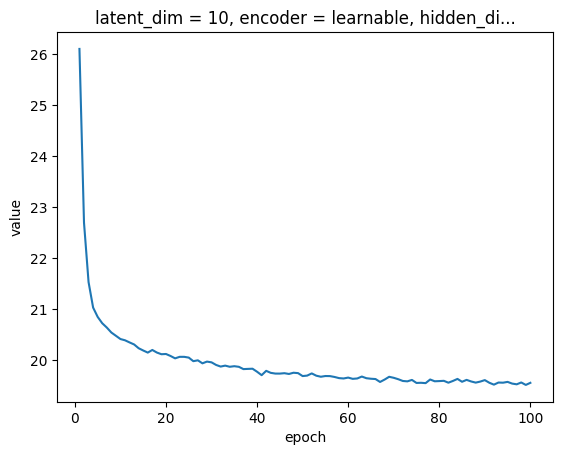

In [14]:
ds.value.sel(latent_dim = 10,
             encoder = 'learnable',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 100,
             lamb = 0.0,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()

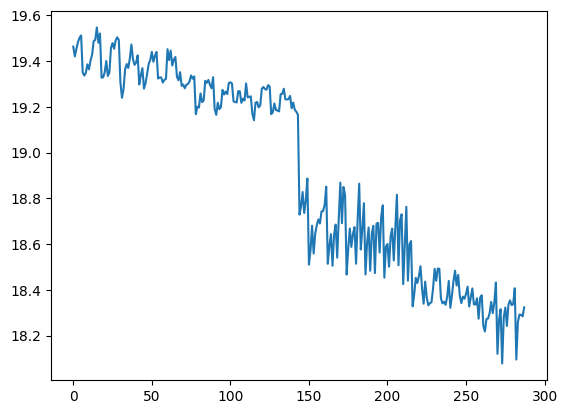

In [30]:
plt.plot(ds.value.sel(loss = "LM NRGY", epoch=100, encoder='learnable', mode='test').values.flatten())

value=18.2095 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 20, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 1.0}
value=18.2171 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 10, 'hidden_dim_lm': 50, 'noise_dim_lm': 100, 'lamb': 0.5}
value=18.2176 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 20, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5}
value=18.2184 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 5, 'hidden_dim_lm': 50, 'noise_dim_lm': 100, 'lamb': 0.5}
value=18.2246 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_dec': 20, 'hidden_dim_lm': 50, 'noise_dim_lm': 20, 'lamb': 0.5}
value=18.2258 at {'latent_dim': 20, 'encoder': 'learnable', 'hidden_dim_NN': 100, 'num_layers_NN': 6, 'noise_dim_d

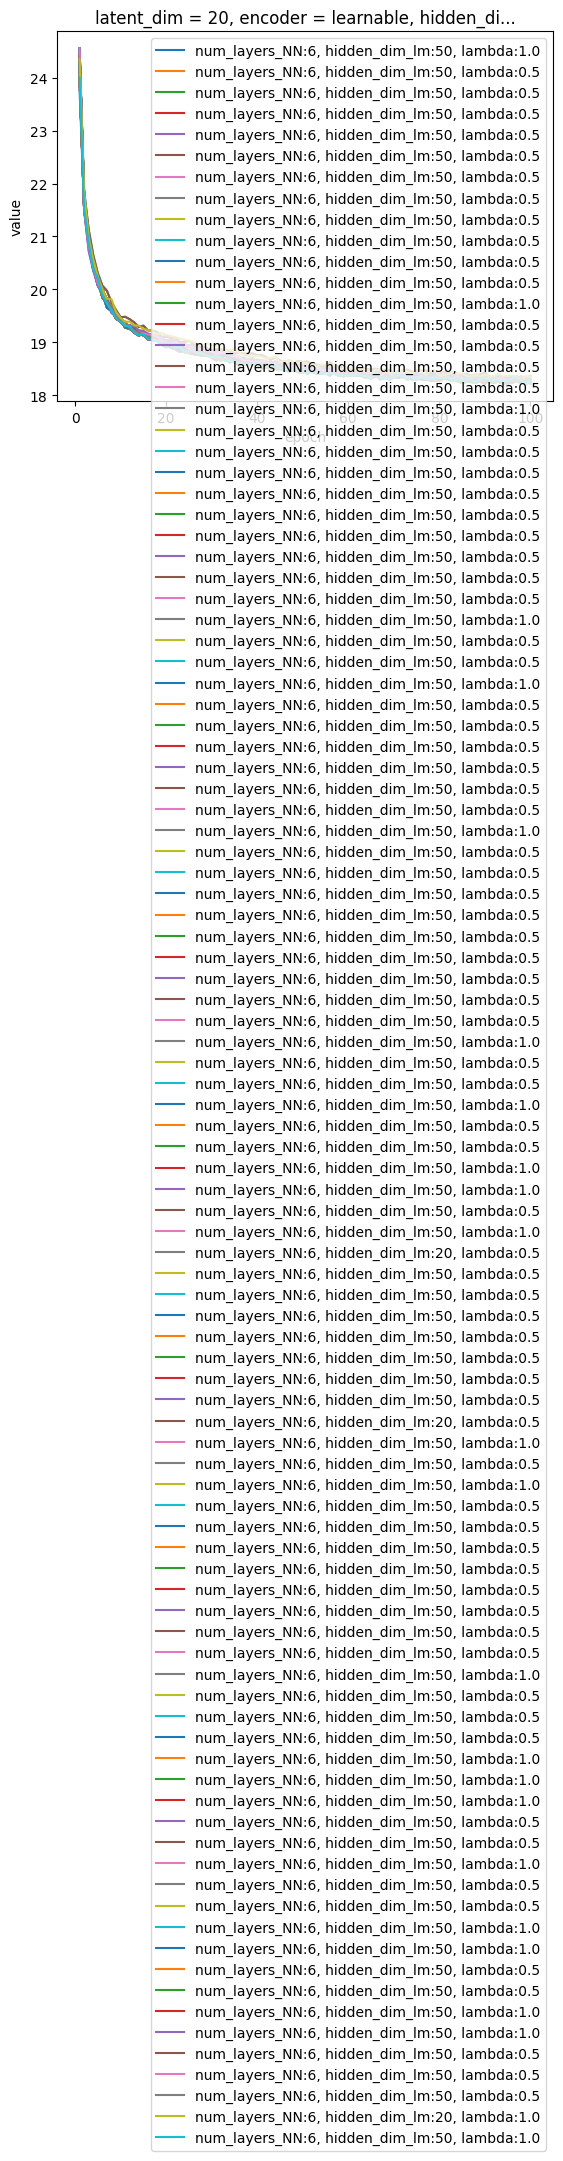

In [18]:
# 1) Turn it into a pandas Series with a MultiIndex
ser = ds.value.sel(loss = 'LM NRGY', mode = 'test', lamb = [0.5, 1.0]).to_series()

# 2) Pick off the 5 smallest values
smallest = ser.nsmallest(100)

# 3) `smallest` is a Series whose index is a tuple of coordinate labels
for coord_tuple, value in smallest.items():
    coords = dict(zip(ds.value.dims, coord_tuple))
    epoch = coords.pop('epoch')
    ds.value.sel(coords).sel(loss = 'LM NRGY', mode = 'test').plot(label = f"num_layers_NN:{coords['num_layers_NN']}, hidden_dim_lm:{coords['hidden_dim_lm']}, lambda:{coords['lamb']}")
    #plt.show()
    plt.legend()
    print(f"value={value:.4f} at {coords}")
plt.show()




In [ ]:
# search for smallest loss value
# vary remaining parameters around it

In [19]:
smallest

latent_dim  encoder    hidden_dim_NN  num_layers_NN  noise_dim_dec  hidden_dim_lm  noise_dim_lm  lamb  epoch
20          learnable  100            6              20             50             20            1.0   99       18.2095
                                                     10             50             100           0.5   90       18.2171
                                                     20             50             20            0.5   95       18.2176
                                                     5              50             100           0.5   100      18.2184
                                                     20             50             20            0.5   94       18.2246
                                                                                                                 ...   
                                                     10             50             100           0.5   83       18.2952
                                                   

In [20]:
type(smallest)

pandas.core.series.Series